# Food Delivery Platform Recommendation System

**Business Context:**  
A food delivery platform wants to recommend restaurants and dishes to users based on their ordering behavior and post-delivery feedback.


## 1) Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 50)


## 2) Load dataset

In [5]:
import pandas as pd

df = pd.read_csv("india_food_delivery_trainer_dataset_realnames.csv")
df.head()

,user_id,restaurant_id,restaurant_name,items,order_time,order_value,cuisine_type,price_range,restaurant_rating,city,area,rating,review,reordered,delivery_time_min,canceled,refund,order_id
0,1,1,Shah Ghouse,"Mutton Biryani, Double Ka Meetha",2025-01-29 19:12:00,327,Biryani,Budget,3.5,Hyderabad,LB Nagar,3.0,Average taste,0,43,0,0,ORD-003028
1,1,7,Meridian Restaurant,"Veg Biryani, Dum Biryani, Double Ka Meetha",2025-03-12 14:43:00,625,Biryani,Mid,4.0,Hyderabad,LB Nagar,3.5,Not bad,0,37,0,0,ORD-009810
2,1,8,Alfa Hotel,"Double Ka Meetha, Mutton Biryani, Veg Biryani",2025-05-21 15:13:00,393,Biryani,Budget,3.7,Hyderabad,Secunderabad,3.2,Could be better,0,41,0,0,ORD-000626
3,1,9,Sarvi,Dum Biryani,2025-01-20 09:16:00,242,Biryani,Budget,4.6,Hyderabad,Ameerpet,4.7,Fresh and hot,0,19,0,0,ORD-011267
4,1,10,Chutneys,Idli,2025-04-15 00:43:00,339,South Indian,Mid,4.3,Hyderabad,Kondapur,4.7,Quick delivery,0,34,0,0,ORD-011385


## 3) Data Validation (Available Data Check)

- **Order history:** user_id, restaurant_id, items, order_time, order_value  
- **Restaurant metadata:** cuisine type, price range, ratings, location  
- **User feedback:** ratings, reviews, reorders  
- **After-order:** delivery time, cancellations, refunds


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            12000 non-null  int64  
 1   restaurant_id      12000 non-null  int64  
 2   restaurant_name    12000 non-null  object 
 3   items              12000 non-null  object 
 4   order_time         12000 non-null  object 
 5   order_value        12000 non-null  int64  
 6   cuisine_type       12000 non-null  object 
 7   price_range        12000 non-null  object 
 8   restaurant_rating  12000 non-null  float64
 9   city               12000 non-null  object 
 10  area               12000 non-null  object 
 11  rating             12000 non-null  float64
 12  review             12000 non-null  object 
 13  reordered          12000 non-null  int64  
 14  delivery_time_min  12000 non-null  int64  
 15  canceled           12000 non-null  int64  
 16  refund             120

## 4) Basic Cleaning / Feature Setup

We will:
- parse `order_time` as datetime
- ensure rating is numeric
- create helper columns for time-based analysis


In [9]:
df["order_time"] = pd.to_datetime(df["order_time"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Simple time helpers
df["hour"] = df["order_time"].dt.hour

# Lunch/Dinner slots for time-based suggestions
df["time_slot"] = df["hour"].apply(
    lambda x: "Lunch" if 11 <= x < 15 else "Dinner" if 18 <= x < 23 else "Other"
)

df[["order_time", "hour", "time_slot"]].head()


,order_time,hour,time_slot
0,2025-01-29 19:12:00,19,Dinner
1,2025-03-12 14:43:00,14,Lunch
2,2025-05-21 15:13:00,15,Other
3,2025-01-20 09:16:00,9,Other
4,2025-04-15 00:43:00,0,Other


# Objective 1: Identify Popular Cuisines by Time and Location

**Goal:**  
Find what people order most, and how it changes by **location (city)** and by **time (lunch vs dinner)**.

**Techniques used here:**  
- Frequency analysis of cuisines and dishes  
- Heatmaps for location vs cuisine popularity


### 1A) Frequency analysis of cuisines (overall)


In [12]:
cuisine_counts = df["cuisine_type"].value_counts()
cuisine_counts


cuisine_type
Biryani          3629
South Indian     3226
Andhra           1091
North Indian      800
Cafe              782
BBQ               534
Chettinad         526
Maharashtrian     300
Mughlai           286
Italian           281
Seafood           279
Parsi             266
Name: count, dtype: int64

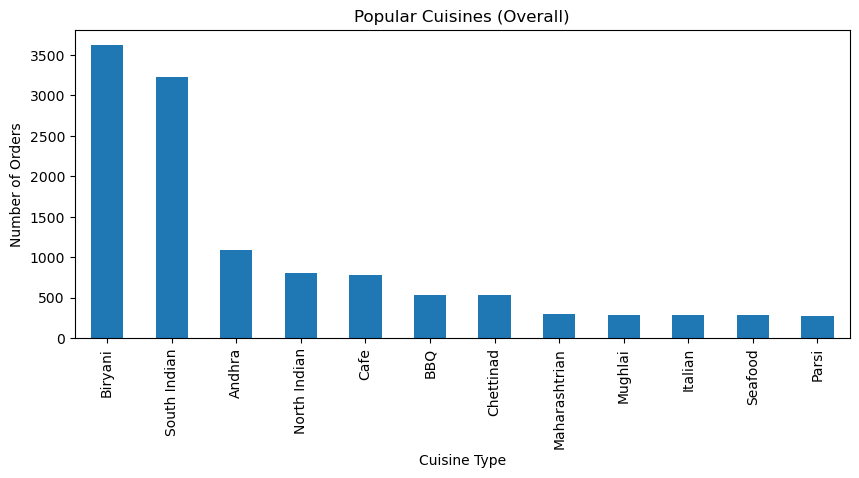

In [13]:
cuisine_counts.plot(kind="bar", figsize=(10,4))
plt.title("Popular Cuisines (Overall)")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.show()


### 1B) Frequency analysis of dishes (overall)


In [15]:
dish_counts = (
    df["items"]
      .astype(str)
      .str.split(",")
      .explode()
      .str.strip()
      .replace("", np.nan)
      .dropna()
      .value_counts()
)

dish_counts.head(15)


items
Dum Biryani         1139
Chicken Biryani     1139
Mutton Biryani      1131
Double Ka Meetha    1117
Veg Biryani         1073
Vada                 866
Idli                 835
Masala Dosa          834
Uttapam              832
Pongal               819
Filter Coffee        812
Chicken Fry          355
Gongura Chicken      342
Andhra Meals         340
Pesarattu            338
Name: count, dtype: int64

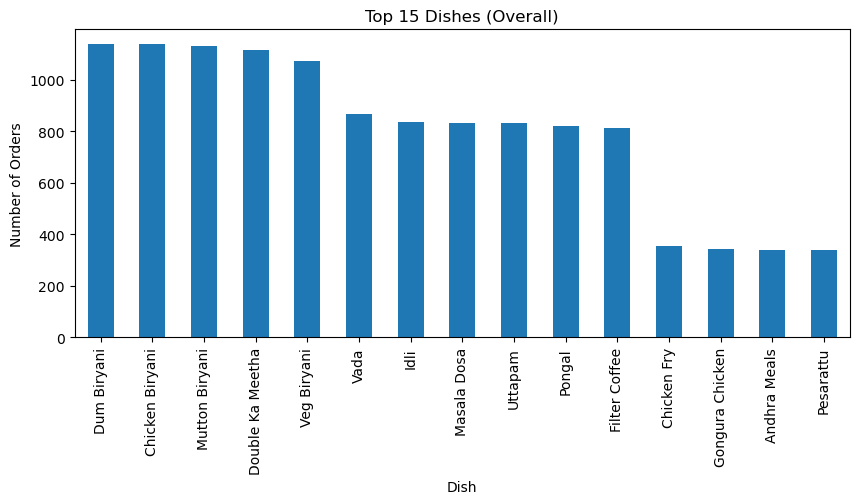

In [16]:
dish_counts.head(15).plot(kind="bar", figsize=(10,4))
plt.title("Top 15 Dishes (Overall)")
plt.xlabel("Dish")
plt.ylabel("Number of Orders")
plt.show()


### 1C) Location vs cuisine heatmap (city × cuisine)


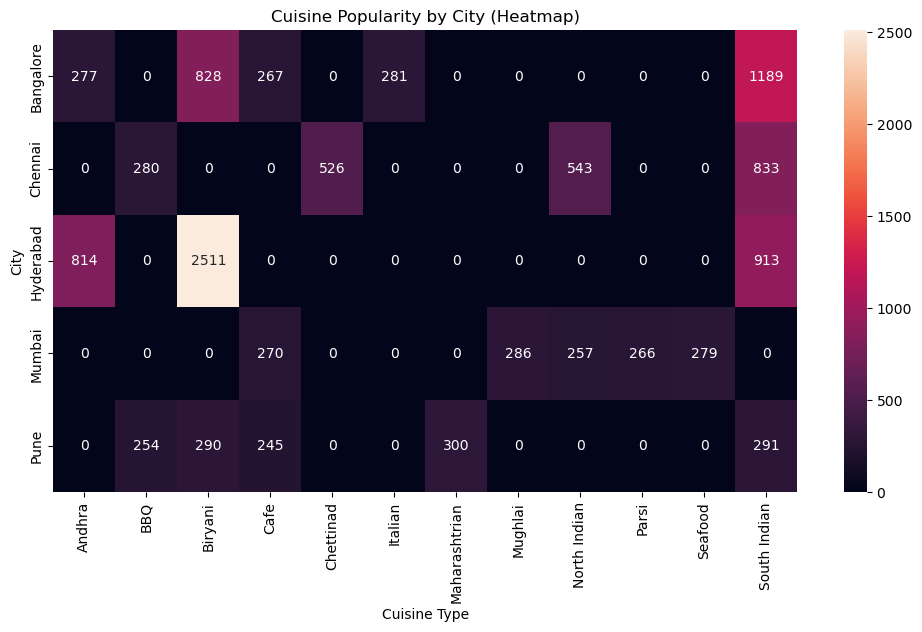

In [18]:
city_cuisine = pd.crosstab(df["city"], df["cuisine_type"])

plt.figure(figsize=(12,6))
sns.heatmap(city_cuisine, annot=True, fmt="d")
plt.title("Cuisine Popularity by City (Heatmap)")
plt.xlabel("Cuisine Type")
plt.ylabel("City")
plt.show()


### 1D) Time-based cuisine popularity (Lunch vs Dinner)


In [20]:
top_cuisines_by_time = (
    df[df["time_slot"].isin(["Lunch", "Dinner"])]
      .groupby(["time_slot", "cuisine_type"])["order_id"]
      .count()
      .reset_index(name="orders")
      .sort_values(["time_slot", "orders"], ascending=[True, False])
)

# Show top 3 cuisines for Lunch and Dinner
top_cuisines_by_time.groupby("time_slot").head(3)


,time_slot,cuisine_type,orders
2,Dinner,Biryani,764
11,Dinner,South Indian,690
0,Dinner,Andhra,225
14,Lunch,Biryani,591
23,Lunch,South Indian,515
12,Lunch,Andhra,197


### Objective 1 Outcome
- Most popular cuisines and dishes overall (frequency analysis)
- City-wise cuisine differences (heatmap) → supports **location-aware** recommendations
- Lunch vs Dinner top cuisines → supports **time-based** suggestions


# Objective 2: Analyze Repeat Order Patterns

**Goal:**  
See whether users are **one-time** or **repeat** customers, and measure repeat behavior.

**Technique emphasized:**  
- Cohort analysis for repeat customers


### 2A) Repeat order patterns (orders per user)


In [24]:
orders_per_user = df.groupby("user_id")["order_id"].count()
orders_per_user.describe()


count    1499.000000
mean        8.005337
std         2.878951
min         2.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        18.000000
Name: order_id, dtype: float64

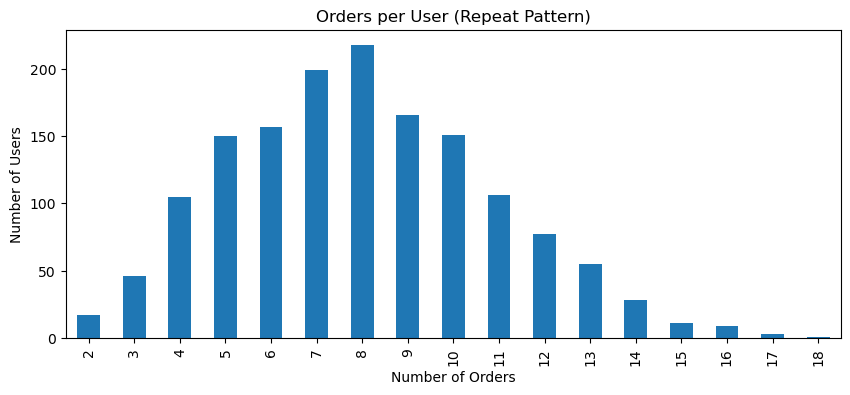

In [25]:
orders_per_user.value_counts().sort_index().plot(kind="bar", figsize=(10,4))
plt.title("Orders per User (Repeat Pattern)")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Users")
plt.show()


### 2B) Repeat rate using reordered flag


In [27]:
df["reordered"].value_counts(), round(df["reordered"].mean() * 100, 2)


(reordered
 0    10956
 1     1044
 Name: count, dtype: int64,
 8.7)

### 2C) Cohort analysis (retention by first order month)


In [29]:
# Cohort month = user's first order month
df["order_month"] = df["order_time"].dt.to_period("M")
first_month = df.groupby("user_id")["order_month"].min()
df = df.join(first_month.rename("cohort_month"), on="user_id")

# Count unique users active in each cohort_month × order_month
cohort_counts = (
    df.groupby(["cohort_month", "order_month"])["user_id"]
      .nunique()
      .reset_index(name="active_users")
)

cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="order_month", values="active_users")
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

retention.round(1).head()


order_month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06
cohort_month,,,,,,
2025-01,100.0,69.5,73.8,71.5,76.9,71.9
2025-02,NaN,NaN,NaN,NaN,NaN,NaN
2025-03,NaN,NaN,NaN,NaN,NaN,NaN
2025-04,NaN,NaN,NaN,NaN,NaN,NaN
2025-05,NaN,NaN,NaN,NaN,NaN,NaN


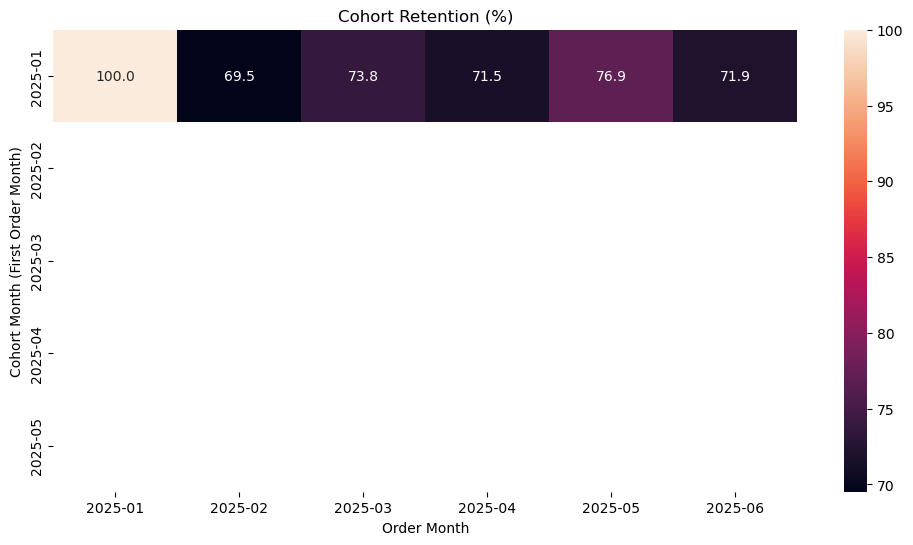

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".1f")
plt.title("Cohort Retention (%)")
plt.xlabel("Order Month")
plt.ylabel("Cohort Month (First Order Month)")
plt.show()


### Objective 2 Outcome
- Users show repeat behavior (orders per user + reorder rate)
- Cohort retention shows how many users return in later months → supports personalization and loyalty-based strategies


# Objective 3: Understand Factors Influencing Low Ratings or Cancellations

**Goal:**  
Find what causes poor experience: do **delivery delays** lead to **low ratings**, **cancellations**, and **refunds**?

**Technique emphasized:**  
- Outlier analysis for delivery delays and refunds


### 3A) Quick stats (checks ranges and extremes/outliers)


In [34]:
df[["delivery_time_min", "rating", "canceled", "refund"]].describe()


,delivery_time_min,rating,canceled,refund
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,33.132000,3.967750,0.030917,0.032000
std,7.346728,0.649079,0.173099,0.176007
min,10.000000,1.000000,0.000000,0.000000
25%,28.000000,3.600000,0.000000,0.000000
50%,33.000000,4.000000,0.000000,0.000000
75%,38.000000,4.400000,0.000000,0.000000
max,61.000000,5.000000,1.000000,1.000000


### 3B) Relationship check: Delivery time vs Rating


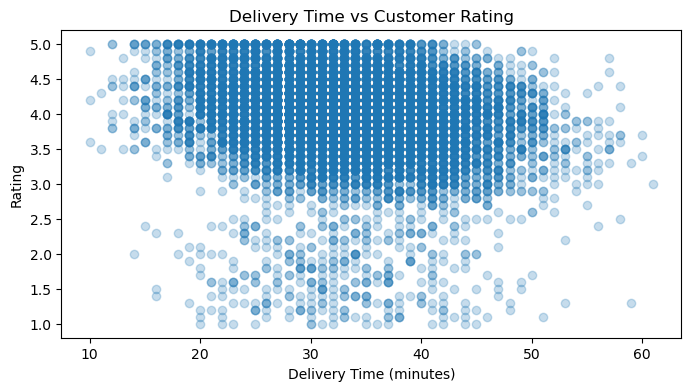

In [36]:
plt.figure(figsize=(8,4))
plt.scatter(df["delivery_time_min"], df["rating"], alpha=0.25)
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.show()


### 3C) Bucket delivery times (makes outliers easy to interpret)


In [38]:
bins = [0, 25, 35, 45, 60, 120]
labels = ["<=25", "26-35", "36-45", "46-60", "60+"]

df["delivery_bucket"] = pd.cut(df["delivery_time_min"], bins=bins, labels=labels, right=True)
df["delivery_bucket"].value_counts().sort_index()


delivery_bucket
<=25     1772
26-35    5841
36-45    3781
46-60     605
60+         1
Name: count, dtype: int64

### 3D) Average rating by delivery bucket


In [40]:
rating_by_bucket = df.groupby("delivery_bucket", observed=True)["rating"].mean().round(2)
rating_by_bucket


delivery_bucket
<=25     4.14
26-35    4.00
36-45    3.87
46-60    3.72
60+      3.00
Name: rating, dtype: float64

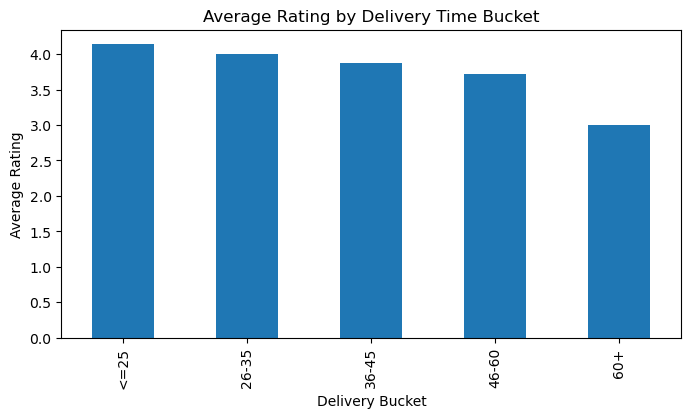

In [41]:
rating_by_bucket.plot(kind="bar", figsize=(8,4))
plt.title("Average Rating by Delivery Time Bucket")
plt.xlabel("Delivery Bucket")
plt.ylabel("Average Rating")
plt.show()


### 3E) Cancellation rate by delivery bucket


In [43]:
cancel_rate_by_bucket = (df.groupby("delivery_bucket", observed=True)["canceled"].mean() * 100).round(2)
cancel_rate_by_bucket


delivery_bucket
<=25     3.78
26-35    3.05
36-45    2.91
46-60    2.64
60+      0.00
Name: canceled, dtype: float64

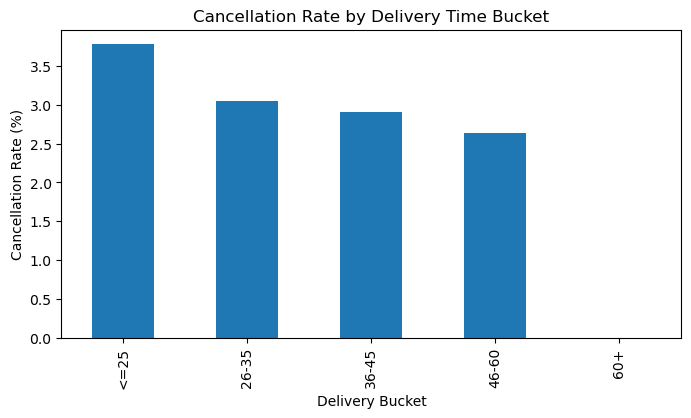

In [44]:
cancel_rate_by_bucket.plot(kind="bar", figsize=(8,4))
plt.title("Cancellation Rate by Delivery Time Bucket")
plt.xlabel("Delivery Bucket")
plt.ylabel("Cancellation Rate (%)")
plt.show()


### 3F) Refund rate by delivery bucket (trainer-required part)


In [46]:
refund_rate_by_bucket = (df.groupby("delivery_bucket", observed=True)["refund"].mean() * 100).round(2)
refund_rate_by_bucket


delivery_bucket
<=25     3.78
26-35    3.06
36-45    3.09
46-60    3.47
60+      0.00
Name: refund, dtype: float64

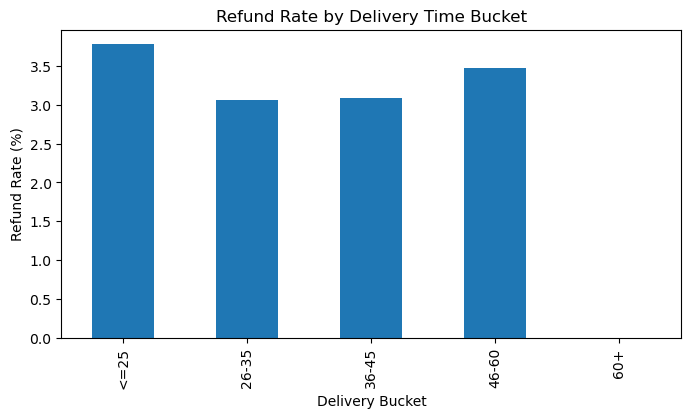

In [47]:
refund_rate_by_bucket.plot(kind="bar", figsize=(8,4))
plt.title("Refund Rate by Delivery Time Bucket")
plt.xlabel("Delivery Bucket")
plt.ylabel("Refund Rate (%)")
plt.show()


### 3G) Outlier detection (IQR) for delivery delays


In [49]:
Q1 = df["delivery_time_min"].quantile(0.25)
Q3 = df["delivery_time_min"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df["delivery_time_min"] > upper]
upper, outliers.shape[0], outliers[["delivery_time_min", "rating", "canceled", "refund"]].head()


(53.0,
 51,
      delivery_time_min  rating  canceled  refund
 145                 57     3.3         0       0
 248                 55     2.7         0       0
 303                 58     2.5         0       1
 355                 57     3.5         0       0
 409                 56     3.5         0       0)

### 3H) Restaurant-level risk list (restaurants to avoid recommending)


In [51]:
restaurant_risk = (
    df.groupby("restaurant_name")
      .agg(
          avg_rating=("rating", "mean"),
          cancel_rate=("canceled", "mean"),
          refund_rate=("refund", "mean"),
          avg_delivery=("delivery_time_min", "mean"),
          orders=("order_id", "count")
      )
      .round(2)
)

# Keep only restaurants with enough orders to be fair
restaurant_risk = restaurant_risk[restaurant_risk["orders"] >= 50].copy()

do_not_recommend = restaurant_risk[
    (restaurant_risk["avg_rating"] < 3.3) |
    (restaurant_risk["cancel_rate"] > 0.08) |
    (restaurant_risk["refund_rate"] > 0.06) |
    (restaurant_risk["avg_delivery"] > 50)
].sort_values(["avg_rating", "cancel_rate"], ascending=[True, False])

do_not_recommend.head(15)


,avg_rating,cancel_rate,refund_rate,avg_delivery,orders
restaurant_name,,,,,


### Objective 3 Outcome
- Delivery delays relate to lower ratings, higher cancellations, and higher refunds
- Outlier analysis isolates extreme delivery delays
- Restaurant risk list identifies poor performers (useful for quality-aware recommendations)


# Objective 4: Segment Users Based on Food Preferences and Spending Behavior

**Goal:**  
Group users by how much they spend and what they like ordering (preferences).

This supports **personalization** in recommendations.


### 4A) User-level spending and frequency features


In [55]:
user_summary = df.groupby("user_id").agg(
    total_orders=("order_id", "count"),
    avg_order_value=("order_value", "mean"),
    total_spent=("order_value", "sum")
).round(2)

user_summary.head()


,total_orders,avg_order_value,total_spent
user_id,,,
1,13,357.85,4652
2,6,365.33,2192
3,6,341.17,2047
4,5,382.00,1910
5,5,305.60,1528


### 4B) Preferred cuisine per user (preference extraction)


In [57]:
user_pref = (
    df.groupby(["user_id", "cuisine_type"])["order_id"]
      .count()
      .reset_index(name="orders")
      .sort_values(["user_id", "orders"], ascending=[True, False])
      .drop_duplicates("user_id")
      .set_index("user_id")["cuisine_type"]
)

user_summary["preferred_cuisine"] = user_pref
user_summary.head()


,total_orders,avg_order_value,total_spent,preferred_cuisine
user_id,,,,
1,13,357.85,4652,Biryani
2,6,365.33,2192,Biryani
3,6,341.17,2047,South Indian
4,5,382.00,1910,Biryani
5,5,305.60,1528,Cafe


### 4C) Simple segments (spend + frequency)


In [59]:
user_summary["spend_segment"] = pd.qcut(user_summary["avg_order_value"], 3, labels=["Low", "Medium", "High"])
user_summary["freq_segment"] = pd.qcut(user_summary["total_orders"], 3, labels=["Occasional", "Regular", "Frequent"])

user_summary.head()


,total_orders,avg_order_value,total_spent,preferred_cuisine,spend_segment,freq_segment
user_id,,,,,,
1,13,357.85,4652,Biryani,Medium,Frequent
2,6,365.33,2192,Biryani,Medium,Occasional
3,6,341.17,2047,South Indian,Medium,Occasional
4,5,382.00,1910,Biryani,High,Occasional
5,5,305.60,1528,Cafe,Low,Occasional


### Objective 4 Outcome
- Users can be segmented into spend levels (Low/Medium/High)
- Users have identifiable preferred cuisine (taste)
- These segments enable personalized recommendations


# Outcome + Recommendation System Demo

It shows:
- Personalized restaurant and dish recommendations
- Time-based suggestions (lunch vs dinner)
- Location-aware recommendations


## Outcome Demo 1: Location-aware restaurant recommendations (per city)


In [63]:
top_restaurants_by_city = (
    df.groupby(["city", "restaurant_name"])["order_id"]
      .count()
      .reset_index(name="orders")
      .sort_values(["city", "orders"], ascending=[True, False])
)

# Example: show Hyderabad top 10
top_restaurants_by_city[top_restaurants_by_city["city"] == "Hyderabad"].head(10)


,city,restaurant_name,orders
31,Hyderabad,Subbayya Gari Hotel,326
21,Hyderabad,Chutneys,311
22,Hyderabad,Dakshin,304
25,Hyderabad,Minerva Coffee Shop,298
18,Hyderabad,Alfa Hotel,290
24,Hyderabad,Meridian Restaurant,284
26,Hyderabad,Paradise Biryani,284
29,Hyderabad,Sarvi,282
30,Hyderabad,Shah Ghouse,278
27,Hyderabad,Pista House,277


## Outcome Demo 2: Time-based suggestions (Lunch vs Dinner)


In [65]:
top_cuisines_by_time.groupby("time_slot").head(5)


,time_slot,cuisine_type,orders
2,Dinner,Biryani,764
11,Dinner,South Indian,690
0,Dinner,Andhra,225
8,Dinner,North Indian,162
3,Dinner,Cafe,152
14,Lunch,Biryani,591
23,Lunch,South Indian,515
12,Lunch,Andhra,197
15,Lunch,Cafe,141
20,Lunch,North Indian,132


## Outcome Demo 3: Personalized baseline (preferred cuisine + city)


In [67]:
def recommend_personalized_baseline(user_id, city, k=5):
    pref = user_summary.loc[user_id, "preferred_cuisine"] if user_id in user_summary.index else None

    city_df = df[df["city"] == city].copy()
    if pref is not None:
        city_df = city_df[city_df["cuisine_type"] == pref]

    # Recommend most ordered restaurants for that city + preferred cuisine
    recs = (city_df.groupby("restaurant_name")["order_id"]
                  .count()
                  .sort_values(ascending=False))

    # Quality-aware filter: remove risky restaurants
    risky = set(do_not_recommend.index)
    recs = recs[~recs.index.isin(risky)]

    return recs.head(k)

# Pick a sample user from the dataset
sample_user = df["user_id"].iloc[0]
sample_city = df[df["user_id"] == sample_user]["city"].iloc[0]

sample_user, sample_city, user_summary.loc[sample_user, "preferred_cuisine"]


(1, 'Hyderabad', 'Biryani')

In [68]:
recommend_personalized_baseline(sample_user, sample_city, k=5)


restaurant_name
Alfa Hotel             290
Meridian Restaurant    284
Paradise Biryani       284
Sarvi                  282
Shah Ghouse            278
Name: order_id, dtype: int64

# MACHINE LEARNING

# Predicting Order Cancellations

## Problem Statement
Using the same food delivery dataset, we predict whether an order will be **cancelled** (`canceled=1`)
based on order details, delivery performance, restaurant attributes, user behavior, and location/time context.

This helps the platform reduce cancellations and improve recommendation quality by avoiding high-risk orders/restaurants.

## Target Variable
- `canceled` (1 = cancelled, 0 = completed) → **Binary Classification**

## Models Used
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier (Boosting algorithm)

## Metrics
- Accuracy, Precision, Recall, F1-score, ROC-AUC


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

import numpy as np
import pandas as pd


In [72]:
# Target (what we predict)
y = df["canceled"].astype(int)

# Features (inputs)
X = df[[
    "order_value",
    "delivery_time_min",
    "rating",
    "refund",
    "reordered",
    "cuisine_type",
    "price_range",
    "restaurant_rating",
    "city",
    "area",
    "time_slot"
]].copy()

X.head()


,order_value,delivery_time_min,rating,refund,reordered,cuisine_type,price_range,restaurant_rating,city,area,time_slot
0,327,43,3.0,0,0,Biryani,Budget,3.5,Hyderabad,LB Nagar,Dinner
1,625,37,3.5,0,0,Biryani,Mid,4.0,Hyderabad,LB Nagar,Lunch
2,393,41,3.2,0,0,Biryani,Budget,3.7,Hyderabad,Secunderabad,Other
3,242,19,4.7,0,0,Biryani,Budget,4.6,Hyderabad,Ameerpet,Other
4,339,34,4.7,0,0,South Indian,Mid,4.3,Hyderabad,Kondapur,Other


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train cancel rate:", round(y_train.mean()*100, 2), "%")
print("Test cancel rate :", round(y_test.mean()*100, 2), "%")


Train cancel rate: 3.09 %
Test cancel rate : 3.08 %


In [74]:
categorical_cols = ["cuisine_type", "price_range", "city", "area", "time_slot"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


In [75]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # Probability for ROC-AUC (only if model supports predict_proba)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = np.nan

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc
    }

    print(f"\n========== {name} ==========")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    return results, pipe


In [76]:
dt_results, dt_pipe = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    X_train, X_test, y_train, y_test
)



========== Decision Tree ==========
Confusion Matrix:
 [[2325    1]
 [   1   73]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2326
           1       0.99      0.99      0.99        74

    accuracy                           1.00      2400
   macro avg       0.99      0.99      0.99      2400
weighted avg       1.00      1.00      1.00      2400



In [77]:
rf_results, rf_pipe = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    X_train, X_test, y_train, y_test
)



========== Random Forest ==========
Confusion Matrix:
 [[2325    1]
 [   0   74]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2326
           1       0.99      1.00      0.99        74

    accuracy                           1.00      2400
   macro avg       0.99      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [78]:
gb_results, gb_pipe = evaluate_model(
    "Gradient Boosting",
    GradientBoostingClassifier(random_state=42),
    X_train, X_test, y_train, y_test
)



========== Gradient Boosting ==========
Confusion Matrix:
 [[2325    1]
 [   0   74]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2326
           1       0.99      1.00      0.99        74

    accuracy                           1.00      2400
   macro avg       0.99      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [79]:
results_df = pd.DataFrame([dt_results, rf_results, gb_results])
results_df.sort_values("f1", ascending=False)


,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.999583,0.986667,1.000000,0.993289,0.999994
2,Gradient Boosting,0.999583,0.986667,1.000000,0.993289,0.999977
0,Decision Tree,0.999167,0.986486,0.986486,0.986486,0.993025


In [80]:
# Predict on test data using Random Forest pipeline
y_pred = rf_pipe.predict(X_test)

# Predicted probabilities (chance of cancellation)
y_prob = rf_pipe.predict_proba(X_test)[:, 1]


In [81]:
predictions_df = pd.DataFrame({
    "Actual_Canceled": y_test.values,
    "Predicted_Canceled": y_pred,
    "Predicted_Probability": y_prob
})

predictions_df.head(15)


,Actual_Canceled,Predicted_Canceled,Predicted_Probability
0,0,0,0.009927
1,0,0,0.016327
2,0,0,0.025106
3,0,0,0.015502
4,0,0,0.018181
5,0,0,0.012089
6,0,0,0.035535
7,0,0,0.013936
8,0,0,0.012518
9,0,0,0.020285


In [82]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.9995833333333334
Precision: 0.9866666666666667
Recall   : 1.0
F1 Score : 0.9932885906040269
ROC AUC  : 0.9999941902349468
